# 14 — Top-40-Frauen (Jahresende 2016–2025) vs. Männer im Elo-Band 2400–2600

**Nachfolger von Notebook 13.** Notebook 13 verglich die statischen Gruppen `female_top`/`male_control` (`players.analysis_group`) — die sich beim Testlauf als nur unvollständig befüllt herausstellten (`groups.backfill_status='partial'`, nur 23/66 bzw. 48/649 Spieler gelabelt, kaum aktive). Dieses Notebook ersetzt die Kohorten-Definition komplett durch eine **dynamische, survivorship-bias-freie** Ableitung aus `rating_history.published_rating` (siehe `docs/ideen_verbesserungen.md`, Abschnitte F2/F7) — keine statischen Labels, keine Pflege, kein Scraping-Backfill nötig.

**Kohorten:**
- **`top40_female`:** alle Frauen, die an mindestens einem der Jahresenden Dez-2016 … Dez-2025 zu den Top 40 nach `published_rating` gehörten (Union über 10 Jahre → 65 Spielerinnen, Cutoff-Rating je Jahr ~2448–2460).
- **`male_2400_2600`:** alle Männer, deren `std_rating` zum Zeitpunkt einer Partie (2016–2025) im Band 2400–2600 lag — eine breite Vergleichspopulation im selben Elo-Band, keine Top-40-Beschränkung (sonst wäre das die absolute Weltspitze ab ~2650, ein anderes Rating-Niveau).

**Zeitfenster:** nur Partien 2016–2025 (Zeitraum, für den die Kohorte definiert wurde) — nicht die gesamte Karriere.

**Definitionen (wie Notebook 13):** Elo-Band = 50-Punkte-Bänder auf `own_rating`; Stärke-Bucket = ±50 Elo relativ zum Gegner; Scope = `open_mixed` vs. `women_only` (`tournament_type ∈ {women, women_team}`), nicht gefiltert sondern parallel ausgewiesen.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
from _setup import load_query, apply_style

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

apply_style()
pd.set_option('display.max_rows', 250)

COHORT_ORDER = ['top40_female', 'male_2400_2600']
COHORT_PALETTE = {'top40_female': '#c0587e', 'male_2400_2600': '#4a7ab5'}

## Datenbasis laden

Zwei Teilabfragen: die Frauen-Kohorte wird per Rang (Top 40 je Jahresende) bestimmt, die Männer-Population per Elo-Band zum Partie-Zeitpunkt — beides direkt aus `rating_history`, ohne `analysis_group`.

In [2]:
sql = '''
WITH female_ranked AS (
    SELECT rh.fide_id,
           ROW_NUMBER() OVER (PARTITION BY rh.period ORDER BY rh.published_rating DESC) AS rnk
    FROM rating_history rh
    JOIN players p ON p.fide_id = rh.fide_id
    WHERE p.sex = 'F'
      AND rh.published_rating IS NOT NULL
      AND rh.period IN ('2016-12-01','2017-12-01','2018-12-01','2019-12-01','2020-12-01',
                        '2021-12-01','2022-12-01','2023-12-01','2024-12-01','2025-12-01')
),
female_cohort AS (
    SELECT DISTINCT fide_id FROM female_ranked WHERE rnk <= 40
)
SELECT
    gr.fide_id, 'top40_female' AS cohort,
    rh.std_rating AS own_rating, gr.opponent_rating, gr.opponent_sex, gr.result,
    gr.rating_change_weighted, gr.expected_score, gr.over_performance, gr.tournament_type
FROM game_results gr
JOIN female_cohort fc        ON fc.fide_id = gr.fide_id
LEFT JOIN rating_history rh  ON rh.fide_id = gr.fide_id AND rh.period = gr.period
WHERE gr.period BETWEEN '2016-01-01' AND '2025-12-31'
  AND gr.opponent_sex IN ('M', 'F')

UNION ALL

SELECT
    gr.fide_id, 'male_2400_2600' AS cohort,
    rh.std_rating AS own_rating, gr.opponent_rating, gr.opponent_sex, gr.result,
    gr.rating_change_weighted, gr.expected_score, gr.over_performance, gr.tournament_type
FROM game_results gr
JOIN players p               ON p.fide_id = gr.fide_id
JOIN rating_history rh       ON rh.fide_id = gr.fide_id AND rh.period = gr.period
WHERE p.sex = 'M'
  AND rh.std_rating BETWEEN 2400 AND 2600
  AND gr.period BETWEEN '2016-01-01' AND '2025-12-31'
  AND gr.opponent_sex IN ('M', 'F')
'''
raw = load_query(sql)
n_raw = len(raw)
df = raw.dropna(subset=['own_rating', 'opponent_rating']).copy()
print(f'{n_raw:,} Partien geladen, {n_raw - len(df):,} ohne own_rating/opponent_rating verworfen '
      f'({(n_raw - len(df)) / n_raw:.1%}) -> {len(df):,} Partien in der Analyse')

df['result'] = df['result'].astype(float)
df['rating_change_weighted'] = df['rating_change_weighted'].astype(float)
df['expected_score'] = df['expected_score'].astype(float)
df['over_performance'] = df['over_performance'].astype(float)
df['own_rating'] = pd.to_numeric(df['own_rating'], errors='coerce')
df['opponent_rating'] = pd.to_numeric(df['opponent_rating'], errors='coerce')
df['diff'] = df['opponent_rating'] - df['own_rating']

def elo_band(r):
    if pd.isna(r):
        return 'unknown'
    lo = int(r // 50) * 50
    return f'{lo}-{lo + 49}'
df['elo_band'] = df['own_rating'].apply(elo_band)

def strength_bucket(d):
    if pd.isna(d):
        return 'unknown'
    if d > 50:
        return 'stärker'
    if d < -50:
        return 'schwächer'
    return 'gleich'
df['strength'] = df['diff'].apply(strength_bucket)

df['scope'] = df['tournament_type'].apply(
    lambda t: 'women_only' if t in ('women', 'women_team') else 'open_mixed'
)

def band_sort_key(b):
    return (9999,) if b == 'unknown' else (int(b.split('-')[0]),)
elo_band_order = sorted(df['elo_band'].unique(), key=band_sort_key)

SEX_ORDER = ['F', 'M']
STRENGTH_ORDER = ['stärker', 'gleich', 'schwächer']
print('Elo-Bänder:', elo_band_order)
df.head()

202,515 Partien geladen, 0 ohne own_rating/opponent_rating verworfen (0.0%) -> 202,515 Partien in der Analyse
Elo-Bänder: ['1700-1749', '1750-1799', '1800-1849', '1850-1899', '1900-1949', '1950-1999', '2000-2049', '2050-2099', '2100-2149', '2150-2199', '2200-2249', '2250-2299', '2300-2349', '2350-2399', '2400-2449', '2450-2499', '2500-2549', '2550-2599', '2600-2649', '2650-2699']


,fide_id,cohort,own_rating,opponent_rating,opponent_sex,result,rating_change_weighted,expected_score,over_performance,tournament_type,diff,elo_band,strength,scope
0,13601458,top40_female,2476,2442,F,0.0,-5.5,0.5488,-0.5488,women_team,-34,2450-2499,gleich,women_only
1,8603642,top40_female,2511,2438,F,1.0,4.0,0.6035,0.3965,women,-73,2500-2549,schwächer,women_only
2,5091756,top40_female,2425,2361,F,0.5,-0.9,0.5911,-0.0911,closed,-64,2400-2449,schwächer,open_mixed
3,13700090,top40_female,2505,2491,F,0.5,-0.2,0.5201,-0.0201,open,-14,2500-2549,gleich,open_mixed
4,35006916,top40_female,2301,2403,F,1.0,6.4,0.3573,0.6427,women,102,2300-2349,stärker,women_only


## 1. Zellgrößen (Plausibilitätscheck)

Die Frauen-Kohorte bleibt mit 65 Spielerinnen klein — Zellen an den Rändern der Elo-Range können dünn besetzt sein. Die Männer-Population ist deutlich größer (587 Spieler).

In [3]:
qc = (
    df.groupby(['cohort', 'elo_band'])
      .agg(n_games=('fide_id', 'size'), n_players=('fide_id', 'nunique'))
      .reset_index()
)
qc.pivot(index='elo_band', columns='cohort', values=['n_games', 'n_players']).reindex(elo_band_order)

n_games                   n_players             
cohort    male_2400_2600 top40_female male_2400_2600 top40_female
elo_band                                                         
1700-1749            NaN         21.0            NaN          1.0
1750-1799            NaN         60.0            NaN          2.0
1800-1849            NaN         10.0            NaN          1.0
1850-1899            NaN         46.0            NaN          2.0
1900-1949            NaN        133.0            NaN          3.0
1950-1999            NaN        112.0            NaN          3.0
2000-2049            NaN         77.0            NaN          5.0
2050-2099            NaN        103.0            NaN          4.0
2100-2149            NaN        200.0            NaN          5.0
2150-2199            NaN        351.0            NaN          6.0
2200-2249            NaN         88.0            NaN          6.0
2250-2299            NaN        449.0            NaN          9.0
2300-2349            NaN       1668.0            NaN         16.0
2350-2399            NaN       3182.0            NaN         27.0
2400-2449        42621.0       6611.0          381.0         38.0
2450-2499        47885.0       8302.0          370.0         45.0
2500-2549        46186.0       3915.0          298.0         28.0
2550-2599        37898.0       1449.0          243.0         11.0
2600-2649          866.0        117.0           58.0          2.0
2650-2699            NaN        165.0            NaN          1.0

## Helper: Metrik-Tabellen

In [4]:
def build_metrics(df_scope):
    g = df_scope.groupby(['elo_band', 'opponent_sex', 'cohort'])
    return g.agg(
        n_games=('fide_id', 'size'),
        n_players=('fide_id', 'nunique'),
        score_rate=('result', 'mean'),
        mean_expected_score=('expected_score', 'mean'),
        mean_over_performance=('over_performance', 'mean'),
        sum_rating_change_weighted=('rating_change_weighted', 'sum'),
        mean_rating_change_weighted=('rating_change_weighted', 'mean'),
    ).reset_index()

def pivot_metric(metrics_df, value_col, round_to=4):
    tbl = metrics_df.pivot(index='elo_band', columns=['opponent_sex', 'cohort'], values=value_col)
    tbl = tbl.reindex(elo_band_order)
    cols = [(s, c) for s in SEX_ORDER for c in COHORT_ORDER if (s, c) in tbl.columns]
    return tbl[cols].round(round_to)

metrics_all = build_metrics(df)
metrics_open = build_metrics(df[df.scope == 'open_mixed'])
print(f'Zellen gesamt: {len(metrics_all)}   Zellen (nur offene Turniere): {len(metrics_open)}')

Zellen gesamt: 49   Zellen (nur offene Turniere): 49


## 2. Haupttabelle — Ø Over-Performance je Elo-Band × Gegner-Geschlecht × Kohorte

`over_performance = result − expected_score` (Elo-Erwartung). Positiv = besser als erwartet.

**Alle Partien:**

In [5]:
pivot_metric(metrics_all, 'mean_over_performance')

opponent_sex            F                           M               
cohort       top40_female male_2400_2600 top40_female male_2400_2600
elo_band                                                            
1700-1749          0.0353            NaN       0.0585            NaN
1750-1799          0.0774            NaN       0.1520            NaN
1800-1849          0.2015            NaN          NaN            NaN
1850-1899          0.1235            NaN      -0.0429            NaN
1900-1949          0.0649            NaN      -0.0165            NaN
1950-1999          0.0949            NaN       0.0581            NaN
2000-2049         -0.0299            NaN       0.2169            NaN
2050-2099          0.1636            NaN       0.0569            NaN
2100-2149          0.0316            NaN       0.0971            NaN
2150-2199          0.0538            NaN       0.0480            NaN
2200-2249          0.0294            NaN       0.1572            NaN
2250-2299          0.0273            NaN       0.0826            NaN
2300-2349          0.0211            NaN       0.0211            NaN
2350-2399          0.0120            NaN       0.0148            NaN
2400-2449          0.0019         0.0067       0.0113         0.0168
2450-2499         -0.0130         0.0009      -0.0024         0.0036
2500-2549         -0.0175         0.0154       0.0004         0.0015
2550-2599         -0.0155         0.0124      -0.0125         0.0030
2600-2649          0.0184         0.0397      -0.0631        -0.0135
2650-2699         -0.0595            NaN      -0.0164            NaN

**Nur offene/gemischte Turniere** (ohne `women`/`women_team`):

In [6]:
pivot_metric(metrics_open, 'mean_over_performance')

opponent_sex            F                           M               
cohort       top40_female male_2400_2600 top40_female male_2400_2600
elo_band                                                            
1700-1749          0.0353            NaN       0.0585            NaN
1750-1799          0.0312            NaN       0.1520            NaN
1800-1849          0.2015            NaN          NaN            NaN
1850-1899          0.1465            NaN      -0.0429            NaN
1900-1949          0.0697            NaN      -0.0165            NaN
1950-1999          0.1348            NaN       0.0581            NaN
2000-2049         -0.0045            NaN       0.2169            NaN
2050-2099          0.1601            NaN       0.0569            NaN
2100-2149          0.0418            NaN       0.0971            NaN
2150-2199          0.0568            NaN       0.0480            NaN
2200-2249         -0.0610            NaN       0.1572            NaN
2250-2299          0.0174            NaN       0.0826            NaN
2300-2349          0.0070            NaN       0.0222            NaN
2350-2399         -0.0003            NaN       0.0139            NaN
2400-2449         -0.0044         0.0065       0.0107         0.0168
2450-2499         -0.0229         0.0013      -0.0024         0.0037
2500-2549         -0.0285         0.0151       0.0004         0.0015
2550-2599         -0.0299         0.0122      -0.0125         0.0030
2600-2649         -0.0084         0.0397      -0.0631        -0.0135
2650-2699         -0.0979            NaN      -0.0164            NaN

### Zum Vergleich: Score-Rate und Ø rating_change_weighted (alle Partien)

In [7]:
pivot_metric(metrics_all, 'score_rate')

opponent_sex            F                           M               
cohort       top40_female male_2400_2600 top40_female male_2400_2600
elo_band                                                            
1700-1749          0.5667            NaN       0.1667            NaN
1750-1799          0.5179            NaN       0.5156            NaN
1800-1849          0.7500            NaN          NaN            NaN
1850-1899          0.7250            NaN       0.0833            NaN
1900-1949          0.6562            NaN       0.5290            NaN
1950-1999          0.7397            NaN       0.4615            NaN
2000-2049          0.6077            NaN       0.5833            NaN
2050-2099          0.5547            NaN       0.4103            NaN
2100-2149          0.6292            NaN       0.5721            NaN
2150-2199          0.6061            NaN       0.4837            NaN
2200-2249          0.6364            NaN       0.6212            NaN
2250-2299          0.6391            NaN       0.5479            NaN
2300-2349          0.6359            NaN       0.5376            NaN
2350-2399          0.6576            NaN       0.5777            NaN
2400-2449          0.6411         0.7667       0.5750         0.6333
2450-2499          0.6241         0.7835       0.5405         0.6420
2500-2549          0.6154         0.8112       0.5387         0.6598
2550-2599          0.6368         0.8172       0.5509         0.6623
2600-2649          0.7982         0.8548       0.4417         0.6443
2650-2699          0.6892            NaN       0.4648            NaN

In [8]:
pivot_metric(metrics_all, 'mean_rating_change_weighted')

opponent_sex            F                           M               
cohort       top40_female male_2400_2600 top40_female male_2400_2600
elo_band                                                            
1700-1749          1.3600            NaN       2.7333            NaN
1750-1799          3.1286            NaN       6.1875            NaN
1800-1849          8.1200            NaN          NaN            NaN
1850-1899          4.8900            NaN      -1.4667            NaN
1900-1949          2.5188            NaN      -0.7188            NaN
1950-1999          3.3929            NaN       1.2569            NaN
2000-2049         -1.2609            NaN       8.8333            NaN
2050-2099          6.5875            NaN       2.2974            NaN
2100-2149          0.8689            NaN       2.9578            NaN
2150-2199          1.9634            NaN       1.8727            NaN
2200-2249         -0.2800            NaN       6.5273            NaN
2250-2299          0.0609            NaN       1.3854            NaN
2300-2349          0.2358            NaN       0.3831            NaN
2350-2399          0.0973            NaN       0.2180            NaN
2400-2449          0.0134         0.0437       0.1054         0.1510
2450-2499         -0.1330        -0.0162      -0.0350         0.0223
2500-2549         -0.1698         0.1255      -0.0055         0.0027
2550-2599         -0.1510         0.0884      -0.1275         0.0187
2600-2649          0.1649         0.3645      -0.6483        -0.1351
2650-2699         -0.5919            NaN      -0.1719            NaN

## 3. Heatmap: Ø Over-Performance nach Elo-Band × Gegner-Geschlecht

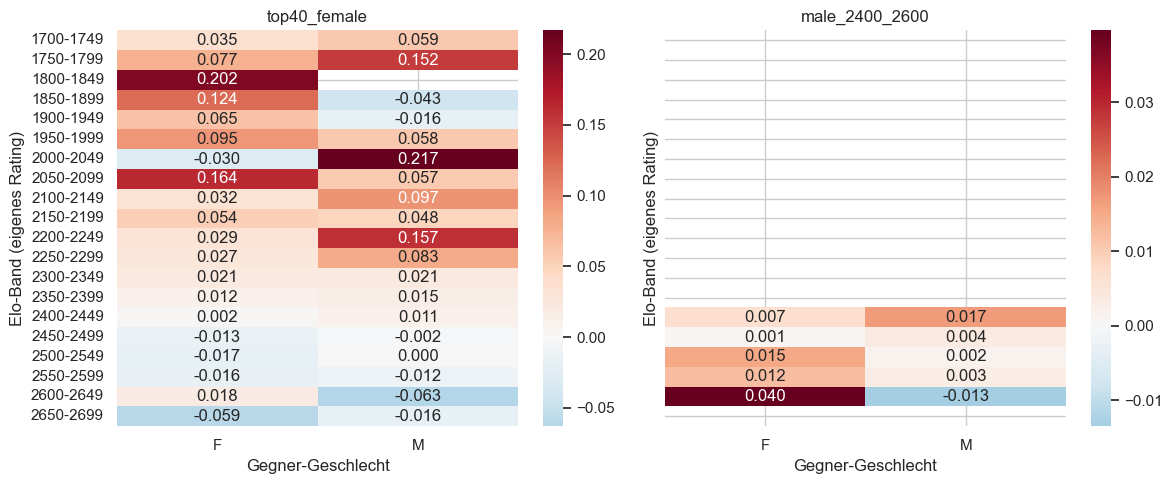

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, coh in zip(axes, COHORT_ORDER):
    sub = (
        metrics_all[metrics_all.cohort == coh]
        .pivot(index='elo_band', columns='opponent_sex', values='mean_over_performance')
        .reindex(index=elo_band_order, columns=SEX_ORDER)
    )
    sns.heatmap(sub, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=ax, cbar=True)
    ax.set_title(coh)
    ax.set_xlabel('Gegner-Geschlecht')
    ax.set_ylabel('Elo-Band (eigenes Rating)')
plt.tight_layout(); plt.show()

## 4. Balkendiagramm: Ø rating_change_weighted je Elo-Band, Kohorte im Vergleich

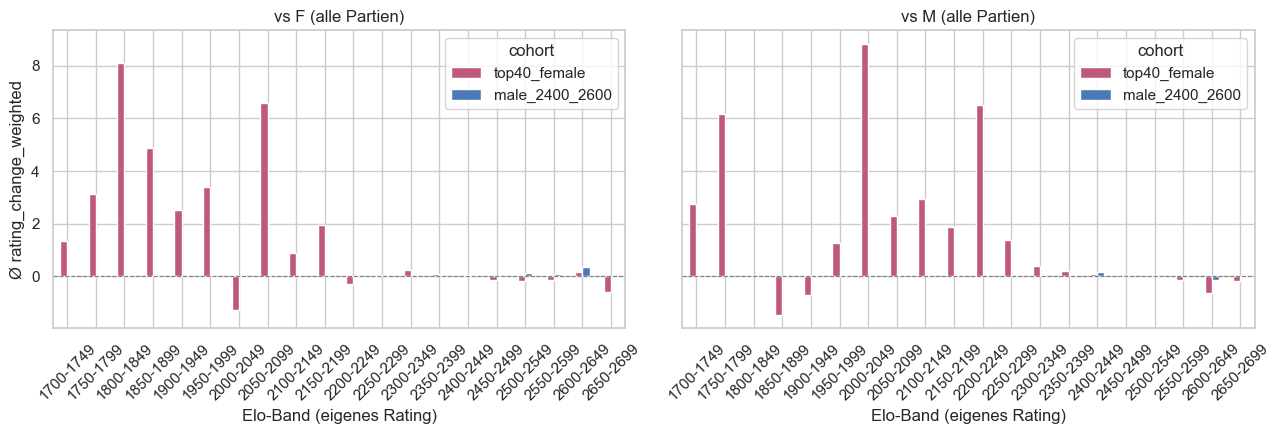

In [10]:
def bar_chart(metrics_df, title_suffix):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
    for ax, sex in zip(axes, SEX_ORDER):
        sub = metrics_df[metrics_df.opponent_sex == sex]
        pv = (
            sub.pivot(index='elo_band', columns='cohort', values='mean_rating_change_weighted')
            .reindex(index=elo_band_order, columns=COHORT_ORDER)
        )
        pv.plot.bar(ax=ax, color=[COHORT_PALETTE[c] for c in COHORT_ORDER], edgecolor='white')
        ax.axhline(0, color='grey', lw=0.8, ls='--')
        ax.set_title(f'vs {sex} ({title_suffix})')
        ax.set_xlabel('Elo-Band (eigenes Rating)')
        ax.set_ylabel('Ø rating_change_weighted')
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout(); plt.show()

bar_chart(metrics_all, 'alle Partien')

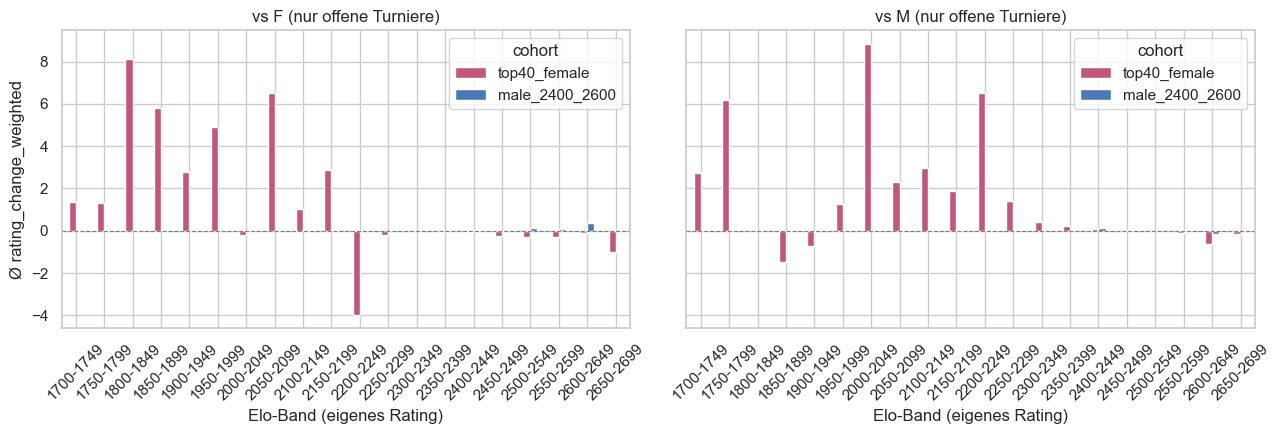

In [11]:
bar_chart(metrics_open, 'nur offene Turniere')

## 5. Sekundärachse: relative Gegnerstärke (±50 Elo)

In [12]:
def build_strength_metrics(df_scope):
    g = df_scope.groupby(['strength', 'opponent_sex', 'cohort'])
    return g.agg(
        n_games=('fide_id', 'size'),
        n_players=('fide_id', 'nunique'),
        score_rate=('result', 'mean'),
        mean_over_performance=('over_performance', 'mean'),
        mean_rating_change_weighted=('rating_change_weighted', 'mean'),
    ).reset_index()

strength_metrics = build_strength_metrics(df)
tbl = strength_metrics.pivot(index='strength', columns=['opponent_sex', 'cohort'], values='mean_over_performance')
tbl = tbl.reindex(STRENGTH_ORDER)
cols = [(s, c) for s in SEX_ORDER for c in COHORT_ORDER if (s, c) in tbl.columns]
tbl[cols].round(4)

opponent_sex            F                           M               
cohort       top40_female male_2400_2600 top40_female male_2400_2600
strength                                                            
stärker            0.0530         0.0459       0.0374         0.0422
gleich             0.0183         0.0436       0.0111         0.0150
schwächer         -0.0203         0.0070      -0.0115        -0.0058

## 6. Signifikanztest

Wie in Notebook 13: Permutationstest auf **Spieler-Ebene** (Ø `over_performance` pro `fide_id`, nicht pro Partie), um den Cluster-Effekt durch stark ungleiche Partienzahlen pro Person zu vermeiden. 10.000 Permutationen, fester Seed, kein scipy/statsmodels nötig. Zellen mit < 8 Spielern in einer Kohorte werden als `underpowered` markiert.

In [13]:
def permutation_test(a, b, n_perm=10000, seed=42, return_diffs=False):
    rng = np.random.default_rng(seed)
    observed = a.mean() - b.mean()
    pooled = np.concatenate([a, b])
    n_a = len(a)
    diffs = np.empty(n_perm)
    for i in range(n_perm):
        rng.shuffle(pooled)
        diffs[i] = pooled[:n_a].mean() - pooled[n_a:].mean()
    p_value = (np.abs(diffs) >= np.abs(observed)).mean()
    return (observed, p_value, diffs) if return_diffs else (observed, p_value)

def player_level_means(df_scope, value_col):
    return df_scope.groupby(['cohort', 'fide_id'])[value_col].mean().reset_index()

SCOPES = {'all': df, 'open_mixed': df[df.scope == 'open_mixed']}
sig_rows = []
for scope_name, dsub in SCOPES.items():
    for band in elo_band_order:
        if band == 'unknown':
            continue
        for sex in SEX_ORDER:
            cell = dsub[(dsub.elo_band == band) & (dsub.opponent_sex == sex)]
            pm = player_level_means(cell, 'over_performance')
            a = pm.loc[pm.cohort == 'top40_female', 'over_performance'].values
            b = pm.loc[pm.cohort == 'male_2400_2600', 'over_performance'].values
            if len(a) == 0 or len(b) == 0:
                continue
            diff, p = permutation_test(a, b)
            sig_rows.append({
                'scope': scope_name, 'elo_band': band, 'opponent_sex': sex,
                'n_players_female': len(a), 'n_players_male': len(b),
                'mean_diff': round(diff, 4), 'p_value': round(p, 4),
                'underpowered': len(a) < 8 or len(b) < 8,
            })
sig_cols = ['scope', 'elo_band', 'opponent_sex', 'n_players_female',
            'n_players_male', 'mean_diff', 'p_value', 'underpowered']
sig_table = pd.DataFrame(sig_rows, columns=sig_cols)
if sig_table.empty:
    print('Keine Zelle hat aktuell Spieler in beiden Kohorten.')
sig_table

,scope,elo_band,opponent_sex,n_players_female,n_players_male,mean_diff,p_value,underpowered
0,all,2400-2449,F,38,322,-0.0055,0.8581,False
1,all,2400-2449,M,35,381,0.0047,0.6890,False
2,all,2450-2499,F,43,305,-0.0198,0.4376,False
3,all,2450-2499,M,40,370,-0.0121,0.3267,False
4,all,2500-2549,F,27,268,-0.0448,0.2047,False
5,all,2500-2549,M,22,298,-0.0189,0.2244,False
6,all,2550-2599,F,11,212,-0.0010,0.9863,False
7,all,2550-2599,M,8,243,-0.0728,0.0084,False
8,all,2600-2649,F,2,18,-0.0097,0.9628,True
9,all,2600-2649,M,2,58,-0.0599,0.4266,True


### Zur Veranschaulichung: Nullverteilung der am besten besetzten Zelle

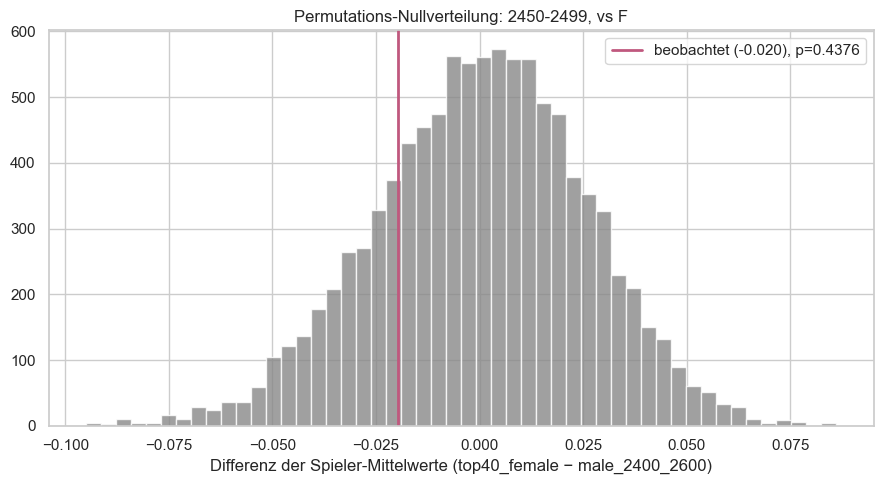

In [14]:
all_scope = sig_table[sig_table.scope == 'all']
if all_scope.empty:
    print('Übersprungen: keine Zelle mit Daten in beiden Kohorten.')
else:
    best = all_scope.sort_values(
        ['n_players_female', 'n_players_male'], ascending=False
    ).iloc[0]
    cell = df[(df.elo_band == best.elo_band) & (df.opponent_sex == best.opponent_sex)]
    pm = player_level_means(cell, 'over_performance')
    a = pm.loc[pm.cohort == 'top40_female', 'over_performance'].values
    b = pm.loc[pm.cohort == 'male_2400_2600', 'over_performance'].values
    observed, p_value, diffs = permutation_test(a, b, return_diffs=True)

    fig, ax = plt.subplots()
    ax.hist(diffs, bins=50, color='#888888', alpha=0.8)
    ax.axvline(observed, color=COHORT_PALETTE['top40_female'], lw=2,
               label=f'beobachtet ({observed:+.3f}), p={p_value:.4f}')
    ax.set_title(f'Permutations-Nullverteilung: {best.elo_band}, vs {best.opponent_sex}')
    ax.set_xlabel('Differenz der Spieler-Mittelwerte (top40_female − male_2400_2600)')
    ax.legend()
    plt.tight_layout(); plt.show()

## Fazit

Die Tabellen in Abschnitt 2 zeigen direkt, ob die Top-40-Frauen der letzten zehn Jahre bei gleichem absoluten Elo-Niveau besser oder schlechter abschneiden als die Vergleichspopulation der Männer im selben Band — getrennt nach Gegner-Geschlecht und mit/ohne Frauen-only-Turniere. Der Permutationstest in Abschnitt 6 zeigt, welche dieser Unterschiede über reine Stichprobenstreuung hinausgehen.

**Caveats:**
- Die Frauen-Kohorte bleibt mit 65 Spielerinnen (52 mit Partien im Fenster 2016–2025) klein — Zellen an den Rändern der Elo-Range sind oft `underpowered`.
- `male_2400_2600` ist eine reine Elo-Band-Population, keine Top-40-Auswahl — das ist beabsichtigt (Top-40-Männer wären ~2650+, ein anderes Niveau), macht die beiden Kohorten aber nicht symmetrisch definiert.
- Der Frauen-Turnier-Bias bleibt in der `all`-Sicht enthalten; `open_mixed` ist die fairere Vergleichsbasis, hat aber pro Zelle weniger Partien.